In [2]:
import os
import glob

print("Admissions clean:")
print(glob.glob("../**/admissions_clean.csv", recursive=True))

print("\nDepartments clean:")
print(glob.glob("../**/departments_clean.csv", recursive=True))

print("\nFacility geocodes:")
print(glob.glob("../**/facility_geocodes.csv", recursive=True))

Admissions clean:
['../milestone2/data/admissions_clean.csv', '../data/processed/admissions_clean.csv', '../milestone3/data/processed/admissions_clean.csv']

Departments clean:
['../milestone2/data/departments_clean.csv', '../data/processed/departments_clean.csv', '../milestone3/data/processed/departments_clean.csv']

Facility geocodes:
[]


In [3]:
import pandas as pd

admissions = pd.read_csv("../data/processed/admissions_clean.csv")
departments = pd.read_csv("../data/processed/departments_clean.csv")
geocodes = pd.read_csv("../data/raw/facility_geocodes.csv")

print("Admissions shape:", admissions.shape)
print("Departments shape:", departments.shape)
print("Geocodes shape:", geocodes.shape)

Admissions shape: (5000, 8)
Departments shape: (20, 2)
Geocodes shape: (20, 4)


In [4]:
print("Admissions columns:")
print(admissions.columns.tolist())

print("\nDepartments columns:")
print(departments.columns.tolist())

print("\nGeocodes columns:")
print(geocodes.columns.tolist())

Admissions columns:
['Admission_ID', 'Patient_ID', 'Doctor_ID', 'Department_ID', 'Admission_Date', 'Discharge_Date', 'Status', 'Length_of_Stay_Days']

Departments columns:
['department_id', 'department_name']

Geocodes columns:
['department_id', 'department_name', 'latitude', 'longitude']


In [5]:
admissions = admissions.rename(columns={
    "Department_ID": "department_id"
})

print(admissions.columns.tolist())

['Admission_ID', 'Patient_ID', 'Doctor_ID', 'department_id', 'Admission_Date', 'Discharge_Date', 'Status', 'Length_of_Stay_Days']


In [6]:
patient_location = admissions.merge(
    geocodes,
    on="department_id",
    how="left"
)

print("Merged shape:", patient_location.shape)
patient_location.head()

Merged shape: (5000, 11)


,Admission_ID,Patient_ID,Doctor_ID,department_id,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days,department_name,latitude,longitude
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8,Neurology,17.3997,78.476
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2,Endocrinology,17.3450,78.540
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9,Dental,17.4700,78.455
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2,Pediatrics,17.4401,78.498
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1,Ophthalmology,17.3950,78.505


In [7]:
department_patient_volume = (
    patient_location
    .groupby(["department_id", "department_name"])
    .agg(
        patient_count=("Patient_ID", "nunique"),
        admission_count=("Admission_ID", "count")
    )
    .reset_index()
)

department_patient_volume

,department_id,department_name,patient_count,admission_count
0,D001,Cardiology,233,233
1,D002,Neurology,200,200
2,D003,Orthopedics,320,320
3,D004,Pediatrics,277,277
4,D005,Oncology,331,331
5,D006,ENT,215,215
6,D007,Dermatology,179,179
7,D008,General Surgery,175,175
8,D009,Urology,169,169
9,D010,Nephrology,218,218


In [8]:
# Calculate patient distribution percentage
total_patients = department_patient_volume["patient_count"].sum()

department_patient_volume["patient_percentage"] = (
    department_patient_volume["patient_count"] / total_patients
) * 100

department_patient_volume = department_patient_volume.sort_values(
    "patient_count",
    ascending=False
)

department_patient_volume


,department_id,department_name,patient_count,admission_count,patient_percentage
14,D015,Emergency,335,335,6.70
4,D005,Oncology,331,331,6.62
2,D003,Orthopedics,320,320,6.40
18,D019,Endocrinology,319,319,6.38
12,D013,Pulmonology,317,317,6.34
3,D004,Pediatrics,277,277,5.54
17,D018,Ophthalmology,268,268,5.36
15,D016,Radiology,266,266,5.32
13,D014,Gastroenterology,260,260,5.20
19,D020,Dental,253,253,5.06


In [9]:
# Find departments with the highest patient volume

top_departments = department_patient_volume.head(5)

print("Top 5 Departments by Patient Volume:")
print(top_departments[
    ["department_id", "department_name", "patient_count", "patient_percentage"]
])

Top 5 Departments by Patient Volume:
   department_id department_name  patient_count  patient_percentage
14          D015       Emergency            335                6.70
4           D005        Oncology            331                6.62
2           D003     Orthopedics            320                6.40
18          D019   Endocrinology            319                6.38
12          D013     Pulmonology            317                6.34


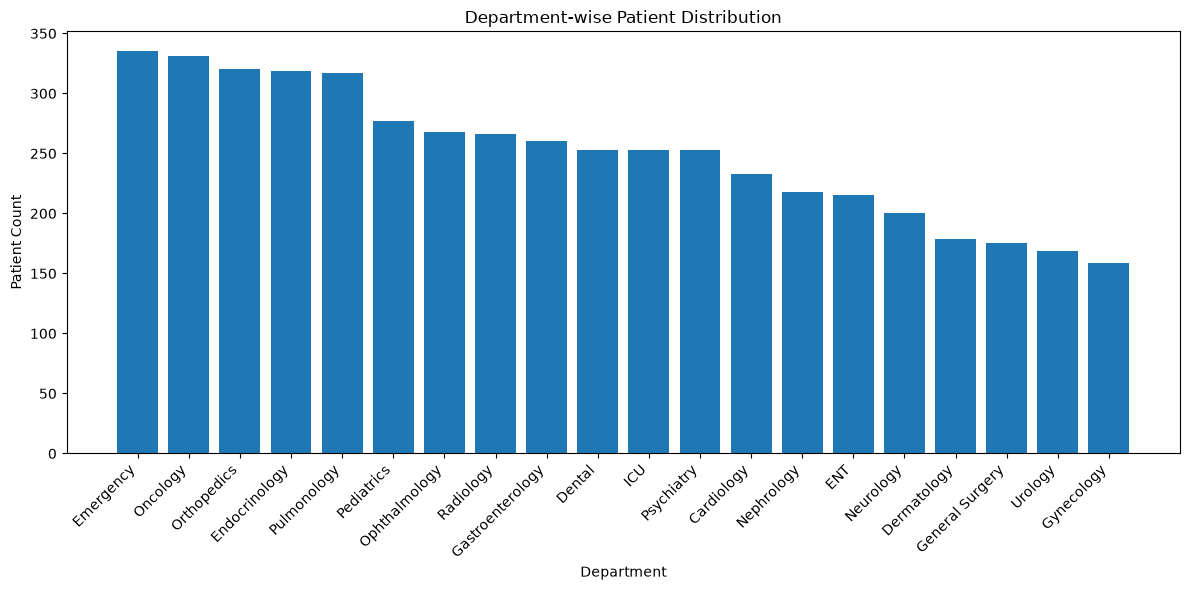

In [11]:
import matplotlib.pyplot as plt

# Create a bar chart for department-wise patient volume
plt.figure(figsize=(12, 6))

plt.bar(
    department_patient_volume["department_name"],
    department_patient_volume["patient_count"]
)

plt.xlabel("Department")
plt.ylabel("Patient Count")
plt.title("Department-wise Patient Distribution")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
location_patient_volume = (
    patient_location
    .groupby(["department_id", "department_name", "latitude", "longitude"])
    .agg(
        patient_count=("Patient_ID", "nunique"),
        admission_count=("Admission_ID", "count")
    )
    .reset_index()
    .sort_values("patient_count", ascending=False)
)

location_patient_volume

,department_id,department_name,latitude,longitude,patient_count,admission_count
14,D015,Emergency,17.4200,78.5650,335,335
4,D005,Oncology,17.3900,78.5200,331,331
2,D003,Orthopedics,17.3715,78.4870,320,320
18,D019,Endocrinology,17.3450,78.5400,319,319
12,D013,Pulmonology,17.4050,78.4550,317,317
3,D004,Pediatrics,17.4401,78.4980,277,277
17,D018,Ophthalmology,17.3950,78.5050,268,268
15,D016,Radiology,17.3750,78.5350,266,266
13,D014,Gastroenterology,17.3350,78.4750,260,260
19,D020,Dental,17.4700,78.4550,253,253


In [13]:
# Identify the highest and lowest patient-volume departments

highest = location_patient_volume.iloc[0]
lowest = location_patient_volume.iloc[-1]

print("Highest Patient Volume:")
print(
    highest["department_name"],
    "-",
    highest["patient_count"],
    "patients"
)

print("\nLowest Patient Volume:")
print(
    lowest["department_name"],
    "-",
    lowest["patient_count"],
    "patients"
)

print("\nTotal Patients:", location_patient_volume["patient_count"].sum())
print("Total Departments:", location_patient_volume["department_id"].nunique())

Highest Patient Volume:
Emergency - 335 patients

Lowest Patient Volume:
Gynecology - 159 patients

Total Patients: 5000
Total Departments: 20


In [14]:
# Save the department-wise patient distribution analysis

output_path = "../data/processed/department_patient_distribution.csv"

location_patient_volume.to_csv(output_path, index=False)

print("File saved successfully:")
print(output_path)

File saved successfully:
../data/processed/department_patient_distribution.csv
